# CKA comparison

In this notebook we try to answer the question how much exactly the model see the emotions

In [10]:
import os
from pathlib import Path

cwd = Path.cwd()

if cwd.name == "notebooks":
    os.chdir(cwd.parent)

In [11]:
emotions = ["neutrality", "happiness", "sadness", "anger", "disgust", "fear"]


This section loads the CKA CSVs from `data/analysis/comparing/` and provides interactive plots to compare emotions and see how splitting by sex or age changes activations across layers. 

In [12]:
import glob
import re
from pathlib import Path
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
try:
    import ipywidgets as widgets
    from IPython.display import display
    HAVE_WIDGETS = True
except Exception:
    HAVE_WIDGETS = False

base = Path('data/analysis/comparing')
files = sorted(glob.glob(str(base / '*.csv')))
rows = []
emotion_map = {i: e for i, e in enumerate(emotions)}

for fp in files:
    fname = Path(fp).stem
    df = pd.read_csv(fp)
    value_cols = [c for c in df.columns if c != 'layer']
    if len(value_cols) == 0:
        continue
    value_col = value_cols[0]

    if re.search(r'_VS_|_VS', fname, flags=re.IGNORECASE):
        ctype = 'emotion_pair'
        if 'emotion1' in df.columns and 'emotion2' in df.columns:
            for _, r in df.iterrows():
                e1 = int(r.get('emotion1')) if not pd.isna(r.get('emotion1')) else None
                e2 = int(r.get('emotion2')) if not pd.isna(r.get('emotion2')) else None
                rows.append({'file': fname, 'type': ctype, 'emotion1': e1, 'emotion2': e2, 'layer': int(r['layer']), 'value': float(r[value_col])})
        else:
            parts = re.split(r'_VS_|_VS', fname, flags=re.IGNORECASE)
            if len(parts) >= 2:
                e1_name = parts[0]
                e2_name = parts[1].split('_')[0]
                for _, r in df.iterrows():
                    rows.append({'file': fname, 'type': ctype, 'emotion1': e1_name, 'emotion2': e2_name, 'layer': int(r['layer']), 'value': float(r[value_col])})
    elif re.search(r'_M_vs_F|_m_vs_f', fname):
        ctype = 'sex_split'
        for _, r in df.iterrows():
            rows.append({'file': fname, 'type': ctype, 'label': fname.replace('_cka',''), 'layer': int(r['layer']), 'value': float(r[value_col])})
    elif re.search(r'_o_vs_y|_o_vs_y', fname):
        ctype = 'age_split'
        for _, r in df.iterrows():
            rows.append({'file': fname, 'type': ctype, 'label': fname.replace('_cka',''), 'layer': int(r['layer']), 'value': float(r[value_col])})
    else:
        ctype = 'other'
        for _, r in df.iterrows():
            rows.append({'file': fname, 'type': ctype, 'label': fname.replace('_cka',''), 'layer': int(r['layer']), 'value': float(r[value_col])})

df_all = pd.DataFrame(rows)
def normalize_row(r):
    out = dict(r)
    if out.get('type') == 'emotion_pair':
        e1 = out.get('emotion1')
        e2 = out.get('emotion2')
        if isinstance(e1, (int, float)) and not pd.isna(e1):
            out['emotion1_name'] = emotion_map.get(int(e1), str(e1))
        else:
            out['emotion1_name'] = str(e1) if e1 is not None else ''
        if isinstance(e2, (int, float)) and not pd.isna(e2):
            out['emotion2_name'] = emotion_map.get(int(e2), str(e2))
        else:
            out['emotion2_name'] = str(e2) if e2 is not None else ''
        out['label'] = f"{out['emotion1_name']} vs {out['emotion2_name']}"
    else:
        out['label'] = out.get('label', out.get('file', ''))
    return out

if not df_all.empty:
    df_all = pd.DataFrame([normalize_row(r) for _, r in df_all.iterrows()])

emotion_pairs = sorted(df_all[df_all['type']=='emotion_pair']['label'].unique()) if not df_all.empty else []
sex_splits = sorted(df_all[df_all['type']=='sex_split']['label'].unique()) if not df_all.empty else []
age_splits = sorted(df_all[df_all['type']=='age_split']['label'].unique()) if not df_all.empty else []

print('Found files:', len(files))
print('Rows total:', len(df_all))
print('Emotion pairs:', len(emotion_pairs), ' Sex splits:', len(sex_splits), ' Age splits:', len(age_splits))

Found files: 44
Rows total: 572
Emotion pairs: 43  Sex splits: 0  Age splits: 0


In [13]:
def plot_line(group='emotion_pair', label=None, plot_kind='line'):
    if df_all.empty:
        print('No data loaded')
        return
    sub = df_all[df_all['type']==group].copy()
    if label is None and len(sub['label'].unique())>0:
        label = sorted(sub['label'].unique())[0]
    sub = sub[sub['label']==label]
    if sub.empty:
        print('No rows for selection')
        return
    fig = px.line(sub, x='layer', y='value', markers=True, title=f'{label} ({group})') if plot_kind=='line' else px.bar(sub, x='layer', y='value', title=f'{label} ({group})')
    fig.update_layout(xaxis_title='Layer', yaxis_title='CKA (mean)')
    fig.show()

if HAVE_WIDGETS:
    group_widget = widgets.Dropdown(options=['emotion_pair','sex_split','age_split','other'], value='emotion_pair', description='Group')
    label_widget = widgets.Dropdown(options=emotion_pairs if emotion_pairs else [''], description='Label')
    kind_widget = widgets.Dropdown(options=['line','bar'], value='line', description='Plot')
    def update_labels(*args):
        g = group_widget.value
        options = sorted(df_all[df_all['type']==g]['label'].unique()) if not df_all.empty else ['']
        label_widget.options = options
        if options:
            label_widget.value = options[0]
    group_widget.observe(update_labels, names='value')
    ui = widgets.HBox([group_widget, label_widget, kind_widget])
    out = widgets.interactive_output(plot_line, {'group': group_widget, 'label': label_widget, 'plot_kind': kind_widget})
    display(ui, out)
else:
    print('ipywidgets not available — call plot_line(group, label, plot_kind) manually')

Output()

In [14]:
import pandas as pd
import plotly.express as px

df = df_all[df_all["type"] == "emotion_pair"].copy()

def plot_emotion_vs_all(target_emotion: str):
    sub = df[df["emotion1_name"] == target_emotion]
    if sub.empty:
        print("No data for emotion:", target_emotion)
        return

    order = (
        sub.groupby("emotion2_name")["value"]
        .mean()
        .sort_values(ascending=False)
        .index.tolist()
    )

    fig = px.line(
        sub,
        x="layer",
        y="value",
        color="emotion2_name",
        category_orders={"emotion2_name": order},
        markers=True,
        title=f"{target_emotion} vs all emotions (CKA by layer)"
    )
    fig.update_layout(xaxis_title="Layer", yaxis_title="CKA similarity")
    fig.show()


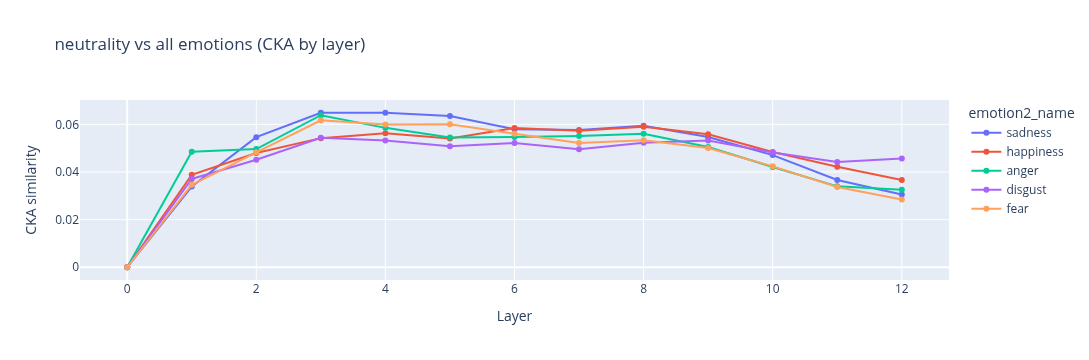

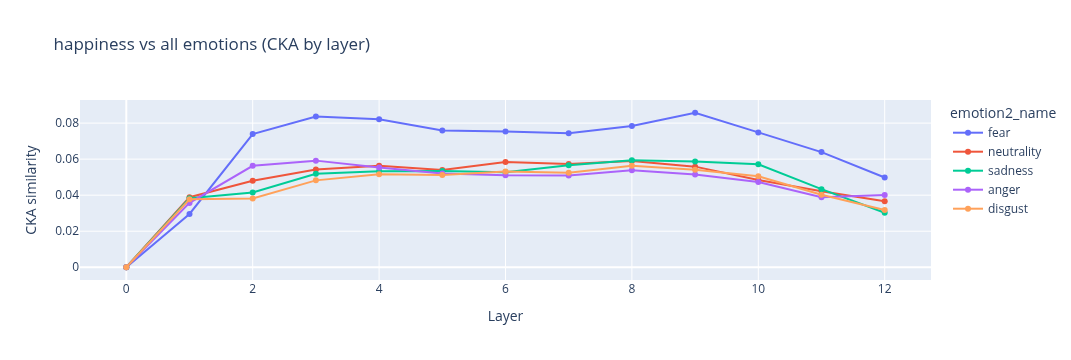

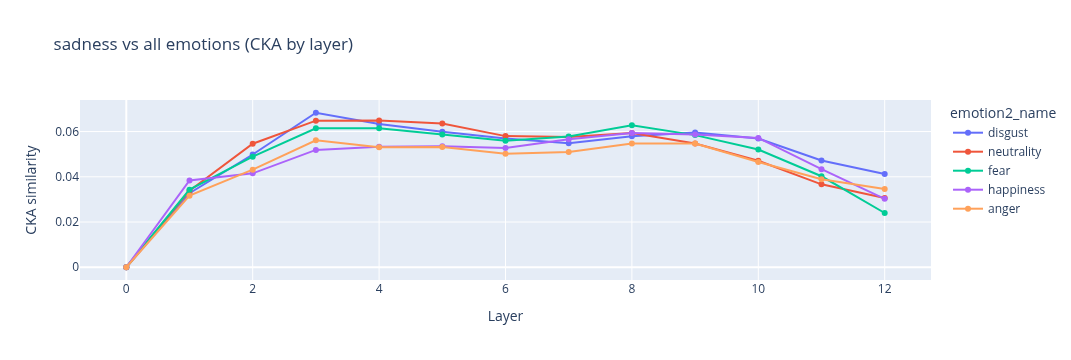

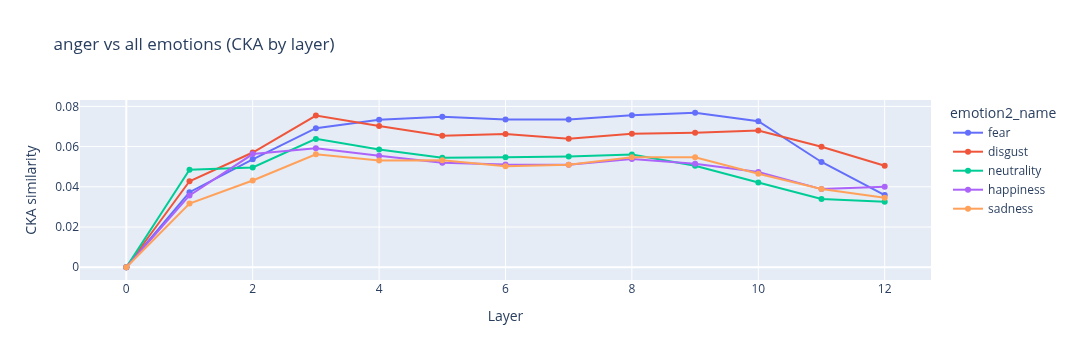

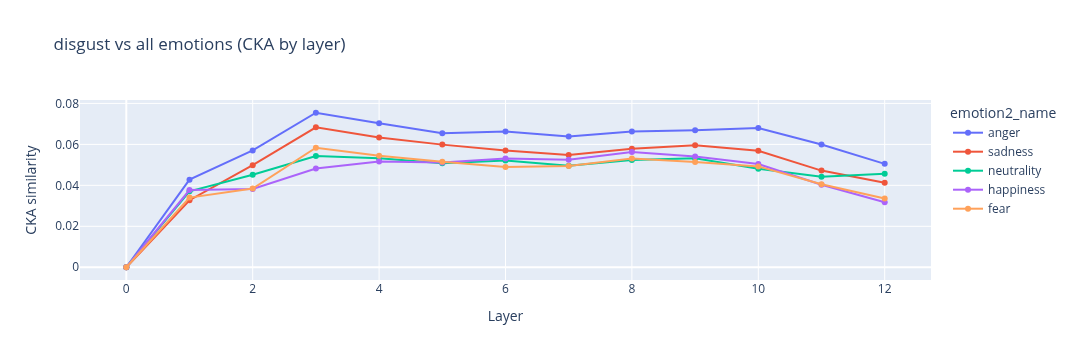

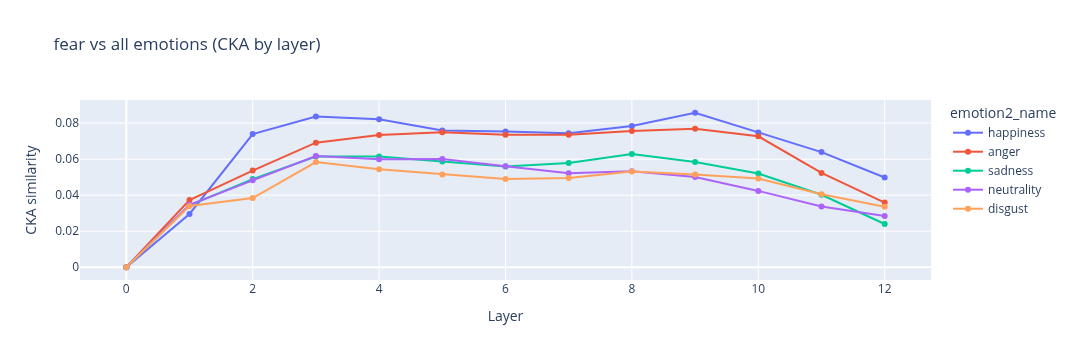

In [15]:
for emo in emotions:
    plot_emotion_vs_all(emo)


In [16]:
import pandas as pd

df = df_all[df_all["type"] == "emotion_pair"].copy()

df_mean = df.groupby(["emotion1_name","emotion2_name"])["value"].mean().reset_index()

rows = []
for emo in df_mean["emotion1_name"].unique():
    sub = df_mean[df_mean["emotion1_name"] == emo]
    if len(sub) < 2:
        continue
    c_row = sub.loc[sub["value"].idxmax()]
    f_row = sub.loc[sub["value"].idxmin()]
    rows.append({
        "emotion": emo,
        "closest": c_row["emotion2_name"],
        "closest_distance": c_row["value"],
        "farthest": f_row["emotion2_name"],
        "farthest_distance": f_row["value"]
    })

result = pd.DataFrame(rows)

print(result)


      emotion    closest  closest_distance farthest  farthest_distance
0       anger       fear          0.059129  sadness           0.043676
1     disgust      anger          0.057912     fear           0.043321
2        fear  happiness          0.065200  disgust           0.043321
3   happiness       fear          0.065200  disgust           0.043490
4  neutrality    sadness          0.048133     fear           0.044651
5     sadness    disgust          0.049910    anger           0.043676


In [17]:
df_all

,file,type,emotion1,emotion2,layer,value,label,emotion1_name,emotion2_name
0,anger_M_vs_F_cka,emotion_pair,anger_M,F,0,3.485084e-13,anger_M vs F,anger_M,F
1,anger_M_vs_F_cka,emotion_pair,anger_M,F,1,6.549419e-02,anger_M vs F,anger_M,F
2,anger_M_vs_F_cka,emotion_pair,anger_M,F,2,7.120515e-02,anger_M vs F,anger_M,F
3,anger_M_vs_F_cka,emotion_pair,anger_M,F,3,1.402061e-01,anger_M vs F,anger_M,F
4,anger_M_vs_F_cka,emotion_pair,anger_M,F,4,1.204601e-01,anger_M vs F,anger_M,F
...,...,...,...,...,...,...,...,...,...
567,vitbase_vs_vitface_cka_results,emotion_pair,vitbase,vitface,8,1.147165e-02,vitbase vs vitface,vitbase,vitface
568,vitbase_vs_vitface_cka_results,emotion_pair,vitbase,vitface,9,7.233812e-03,vitbase vs vitface,vitbase,vitface
569,vitbase_vs_vitface_cka_results,emotion_pair,vitbase,vitface,10,6.406168e-03,vitbase vs vitface,vitbase,vitface
570,vitbase_vs_vitface_cka_results,emotion_pair,vitbase,vitface,11,4.532414e-03,vitbase vs vitface,vitbase,vitface


In [20]:
import glob
import pandas as pd
from pathlib import Path

base = Path("data/analysis/comparing")
files = glob.glob(str(base / "*_M_vs_F_cka.csv"))

rows = []
for fp in files:
    df = pd.read_csv(fp)
    emotion = Path(fp).stem.replace("_M_vs_F_cka", "")

    mean_cka = df["cka_mean_male_vs_female"].mean()
    distance = 1 - mean_cka

    rows.append({
        "emotion": emotion,
        "closest_cka": mean_cka,      
        "farthest_cka": mean_cka,      
        "mean_distance": distance
    })

df_sex = pd.DataFrame(rows)
df_layers = []
for fp in files:
    df = pd.read_csv(fp)
    emotion = Path(fp).stem.replace("_M_vs_F_cka", "")
    df["emotion"] = emotion
    df_layers.append(df)

df_layers = pd.concat(df_layers)

closest = df_layers.groupby("emotion")["cka_mean_male_vs_female"].max()
farthest = df_layers.groupby("emotion")["cka_mean_male_vs_female"].min()

df_sex["closest_layer_cka"] = df_sex["emotion"].map(closest)
df_sex["farthest_layer_cka"] = df_sex["emotion"].map(farthest)

df_sex = df_sex[["emotion", "closest_layer_cka", "farthest_layer_cka", "mean_distance"]]
print(df_sex)


      emotion  closest_layer_cka  farthest_layer_cka  mean_distance
0       anger           0.140206        3.485084e-13       0.908491
1     disgust           0.116093        3.485084e-13       0.915712
2        fear           0.130581        3.485084e-13       0.904045
3   happiness           0.123307        3.485084e-13       0.911137
4  neutrality           0.122868        3.485084e-13       0.917254
5     sadness           0.122488        3.485084e-13       0.916564


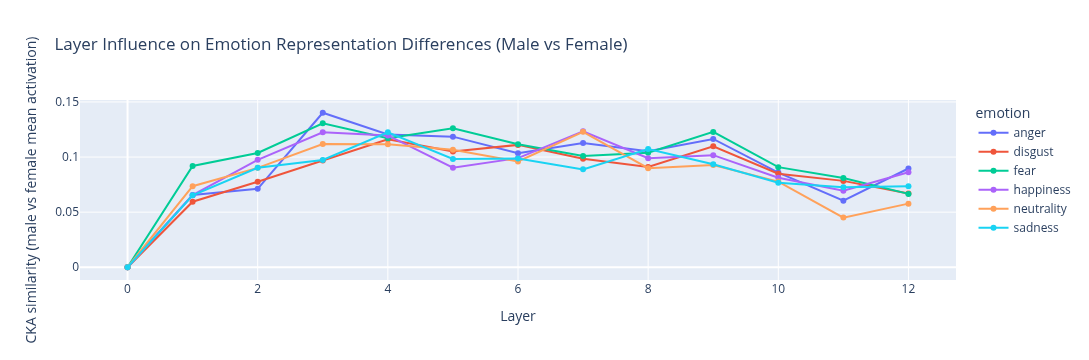

In [21]:
fig = px.line(
    df_layers,
    x="layer",
    y="cka_mean_male_vs_female",
    markers=True,
    color="emotion",
    title="Layer Influence on Emotion Representation Differences (Male vs Female)"
)
fig.update_layout(
    xaxis_title="Layer",
    yaxis_title="CKA similarity (male vs female mean activation)"
)
fig.show()

In [25]:
import glob
import pandas as pd
from pathlib import Path
import plotly.express as px

base = Path("data/analysis/comparing")
files = glob.glob(str(base / "*_o_vs_y_cka.csv"))

layer_dfs = []

for fp in files:
    df = pd.read_csv(fp)

    if "cka_mean_o_vs_y" not in df.columns:
        print("Skipping (missing column):", fp)
        continue

    emotion = Path(fp).stem.replace("_o_vs_y_cka", "")
    df["emotion"] = emotion
    layer_dfs.append(df)

if not layer_dfs:
    raise RuntimeError("No valid age-split CKA files loaded!")

df_layers = pd.concat(layer_dfs, ignore_index=True)

stats = df_layers.groupby("emotion").agg(
    closest_layer=("layer", lambda x: df_layers.loc[x.idxmax(), "layer"]),
    closest_layer_cka=("cka_mean_o_vs_y", "max"),
    farthest_layer=("layer", lambda x: df_layers.loc[x.idxmin(), "layer"]),
    farthest_layer_cka=("cka_mean_o_vs_y", "min"),
    mean_distance=("cka_mean_o_vs_y", lambda x: 1 - x.mean())
).reset_index()

print(stats)



      emotion  closest_layer  closest_layer_cka  farthest_layer  \
0       anger             12           0.159373               0   
1     disgust             12           0.146039               0   
2        fear             12           0.151560               0   
3   happiness             12           0.135405               0   
4  neutrality             12           0.152776               0   
5     sadness             12           0.158880               0   

   farthest_layer_cka  mean_distance  
0        6.335304e-14       0.875143  
1        6.335304e-14       0.884160  
2        6.335304e-14       0.886556  
3        6.335304e-14       0.897996  
4        6.335304e-14       0.884643  
5        6.335304e-14       0.880645  


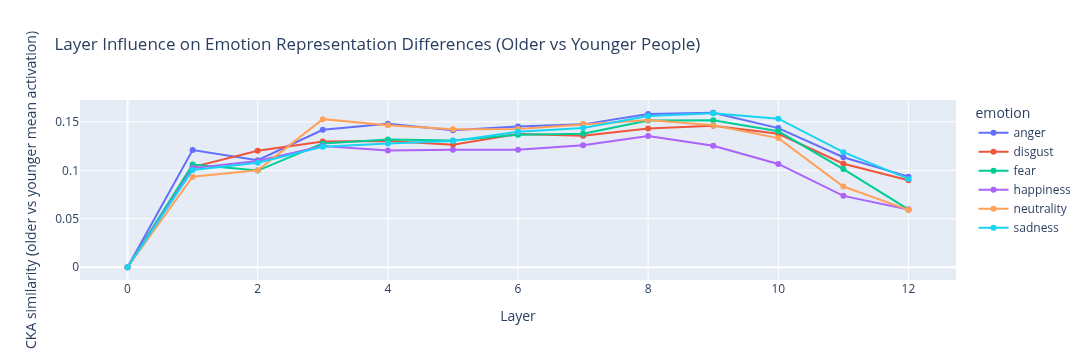

In [26]:

fig = px.line(
    df_layers,
    x="layer",
    y="cka_mean_o_vs_y",
    markers=True,
    color="emotion",
    title="Layer Influence on Emotion Representation Differences (Older vs Younger People)"
)
fig.update_layout(
    xaxis_title="Layer",
    yaxis_title="CKA similarity (older vs younger mean activation)"
)
fig.show()